Warning message:
"package 'lme4' was built under R version 4.5.2"
Loading required package: Matrix

Warning message:
"package 'lmerTest' was built under R version 4.5.2"

Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step


Warning message:
"package 'dplyr' was built under R version 4.5.2"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'readr' was built under R version 4.5.2"
Warning message:
"package 'gridExtra' was built under R version 4.5.2"

Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


Rows: 6834 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): SiteID, period, Protocol, zone


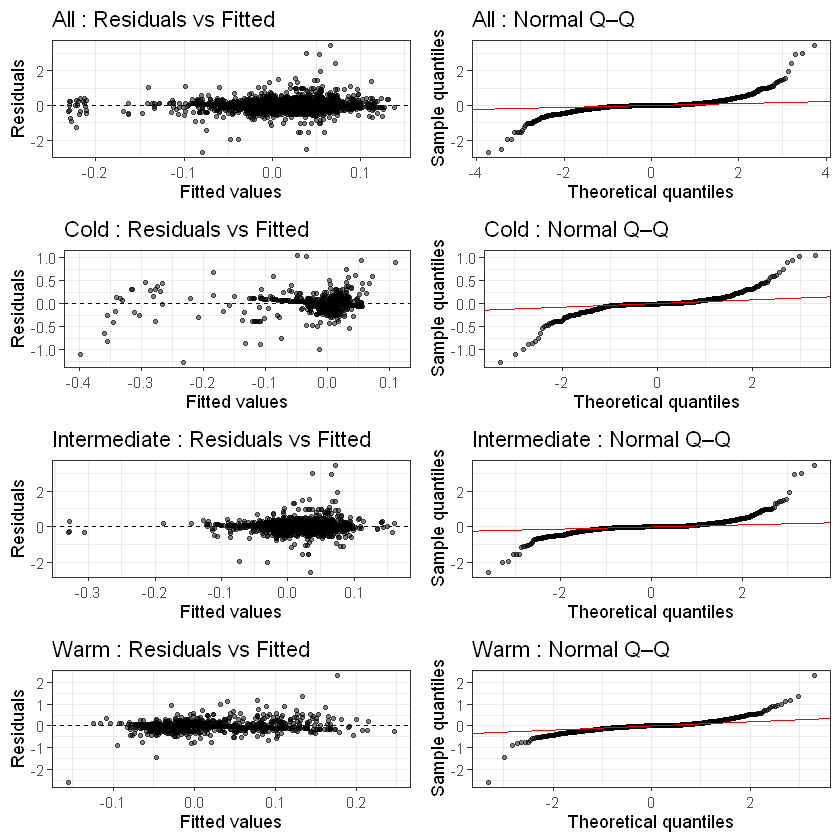

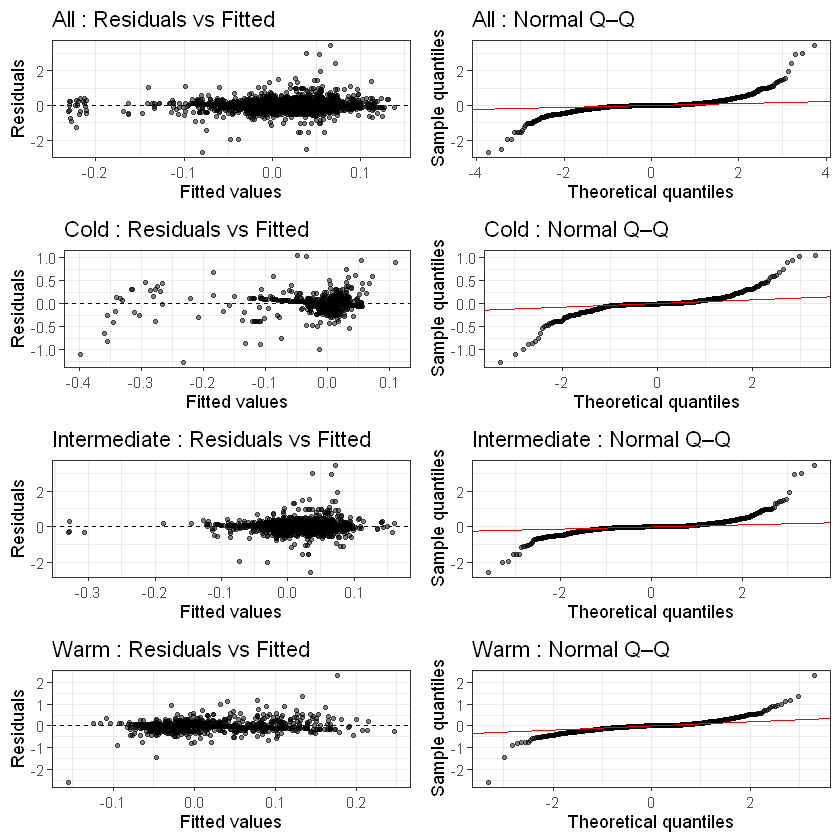

In [ ]:
# =========================================================
# Libraries
# =========================================================
library(lme4)
library(lmerTest)
library(dplyr)
library(readr)
library(ggplot2)
library(gridExtra)

df <- read_csv("D:/NC/Data/rivernet/inputdata/Richness_segmented_2004.csv")
df <- df %>%
  mutate(
    SiteID   = as.character(SiteID),
    HYBAS_ID = as.character(HYBAS_ID),
    Period_bin = ifelse(period == "2005_2018", 1, 0)
  )

num_cols <- c(
  "sen_richness","sen_temp","HFP_period",
  "mean_temp","mean_Q","mean_salinity",
  "mean_organic","elevation"
)
df[num_cols] <- lapply(df[num_cols], as.numeric)

df <- df %>%
  filter(
    complete.cases(
      sen_richness, sen_temp, HFP_period,
      mean_temp, mean_Q, mean_salinity,
      mean_organic, elevation,
      Protocol, zone, HYBAS_ID
    )
  )

# =========================================================
# Z-score
# =========================================================
scale_cols <- c(
  "sen_temp","HFP_period","mean_temp",
  "mean_Q","mean_salinity","mean_organic","elevation"
)
for (v in scale_cols) {
  df[[paste0(v, "_z")]] <- scale(df[[v]])[,1]
}

# =========================================================
# Model formula
# =========================================================
form <- sen_richness ~
  Period_bin +
  sen_temp_z + HFP_period_z + mean_temp_z + mean_Q_z +
  mean_salinity_z + mean_organic_z + elevation_z +
  sen_temp_z:Period_bin +
  HFP_period_z:Period_bin +
  mean_temp_z:Period_bin +
  mean_Q_z:Period_bin +
  mean_salinity_z:Period_bin +
  mean_organic_z:Period_bin +
  elevation_z:Period_bin +
  (1 | HYBAS_ID) + + (1 | Protocol) + (1 | SiteID)

zones <- c("All","Cold","Intermediate","Warm")

# =========================================================
# Function: diagnostic plots for one zone
# =========================================================
plot_diagnostics <- function(dat, zone_name){

  m <- lmer(form, data = dat, REML = TRUE)

  df_diag <- data.frame(
    fitted = fitted(m),
    resid  = resid(m)
  )

  p1 <- ggplot(df_diag, aes(x = fitted, y = resid)) +
    geom_point(alpha = 0.5, size = 1) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(
      title = paste(zone_name, ": Residuals vs Fitted"),
      x = "Fitted values",
      y = "Residuals"
    ) +
    theme_bw()

  # ---- QQ plot ----
  p2 <- ggplot(df_diag, aes(sample = resid)) +
    stat_qq(size = 1, alpha = 0.5) +
    stat_qq_line(color = "red") +
    labs(
      title = paste(zone_name, ": Normal Q–Q"),
      x = "Theoretical quantiles",
      y = "Sample quantiles"
    ) +
    theme_bw()

  list(p1 = p1, p2 = p2)
}

plots <- list()

for (z in zones) {

  dat_z <- if (z == "All") df else filter(df, zone == z)

  pp <- plot_diagnostics(dat_z, z)

  plots[[paste0(z, "_resid")]] <- pp$p1
  plots[[paste0(z, "_qq")]]    <- pp$p2
}

grid.arrange(
  plots[["All_resid"]], plots[["All_qq"]],
  plots[["Cold_resid"]], plots[["Cold_qq"]],
  plots[["Intermediate_resid"]], plots[["Intermediate_qq"]],
  plots[["Warm_resid"]], plots[["Warm_qq"]],
  ncol = 2
)

ggsave(
  filename = "C:/Users/Lenovo/Desktop/S1.png",
  plot = grid.arrange(
    plots[["All_resid"]], plots[["All_qq"]],
    plots[["Cold_resid"]], plots[["Cold_qq"]],
    plots[["Intermediate_resid"]], plots[["Intermediate_qq"]],
    plots[["Warm_resid"]], plots[["Warm_qq"]],
    ncol = 2
  ),
  width = 10,
  height = 12,
  dpi = 300
)

Rows: 51194 Columns: 22
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): SiteID, Species, period, Protocol, zone
dbl (17): sen_abundance_std, p_abundance_std, n_years, mean_salinity, mean_o...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
boundary (singular) fit: see help('isSingular')



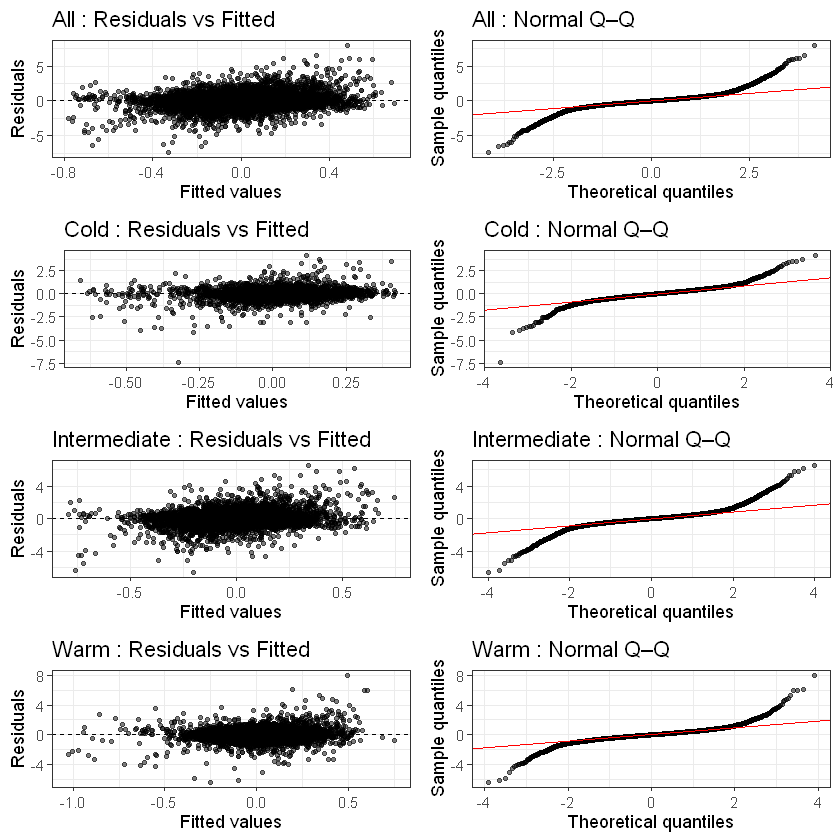

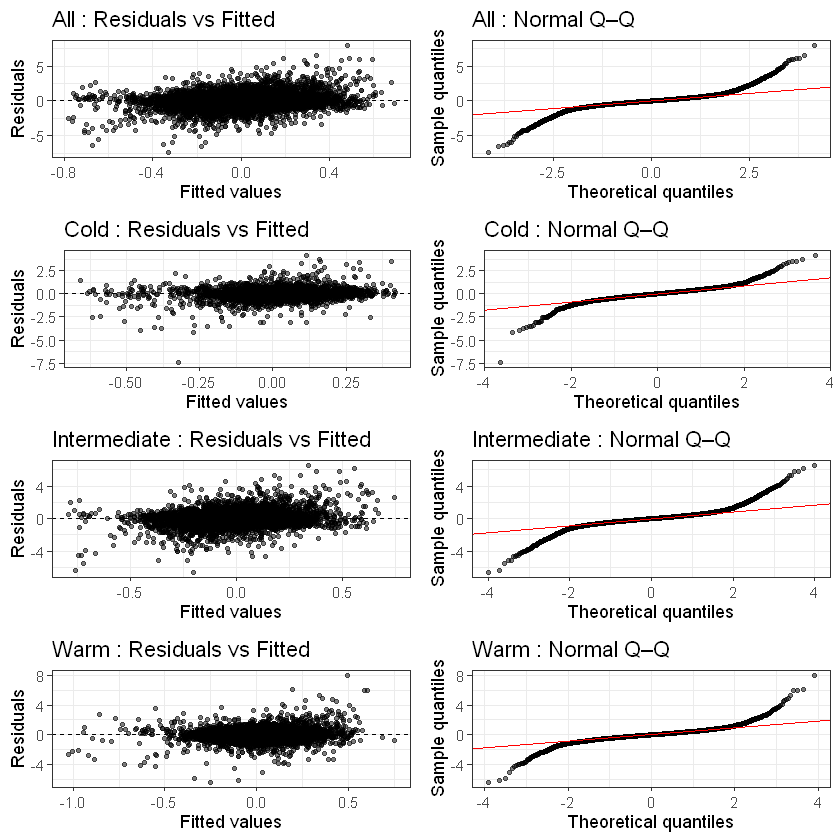

In [ ]:
library(lme4)
library(lmerTest)
library(dplyr)
library(readr)
library(ggplot2)
library(gridExtra)

df <- read_csv("D:/NC/Data/rivernet/inputdata/Abundance_segmented_2004.csv")

df <- df %>%
  mutate(
    SiteID   = as.character(SiteID),
    HYBAS_ID = as.character(HYBAS_ID),
    Species  = as.character(Species),
    Period_bin = ifelse(period == "2005_2018", 1, 0)
  )

num_cols <- c(
  "sen_abundance_std","sen_temp","HFP_period",
  "mean_temp","mean_Q","mean_salinity",
  "mean_organic","elevation"
)

df[num_cols] <- lapply(df[num_cols], as.numeric)

df <- df %>%
  filter(
    complete.cases(
      sen_abundance_std, sen_temp, HFP_period,
      mean_temp, mean_Q, mean_salinity,
      mean_organic, elevation,
      Protocol, zone, HYBAS_ID, Species
    )
  )

scale_cols <- c(
  "sen_temp","HFP_period","mean_temp",
  "mean_Q","mean_salinity","mean_organic","elevation"
)

for (v in scale_cols) {
  df[[paste0(v, "_z")]] <- scale(df[[v]])[,1]
}

form <- sen_abundance_std ~
  Period_bin +
  sen_temp_z + HFP_period_z + mean_temp_z + mean_Q_z +
  mean_salinity_z + mean_organic_z + elevation_z +
  sen_temp_z:Period_bin +
  HFP_period_z:Period_bin +
  mean_temp_z:Period_bin +
  mean_Q_z:Period_bin +
  mean_salinity_z:Period_bin +
  mean_organic_z:Period_bin +
  elevation_z:Period_bin +
  (1 | Species) + (1 | HYBAS_ID) + (1 | SiteID) + (1 | Protocol)

zones <- c("All","Cold","Intermediate","Warm")

plot_diagnostics <- function(dat, zone_name){

  m <- lmer(form, data = dat, REML = TRUE)

  df_diag <- data.frame(
    fitted = fitted(m),
    resid  = resid(m)
  )

  p1 <- ggplot(df_diag, aes(x = fitted, y = resid)) +
    geom_point(alpha = 0.5, size = 1) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(
      title = paste(zone_name, ": Residuals vs Fitted"),
      x = "Fitted values",
      y = "Residuals"
    ) +
    theme_bw()
  p2 <- ggplot(df_diag, aes(sample = resid)) +
    stat_qq(size = 1, alpha = 0.5) +
    stat_qq_line(color = "red") +
    labs(
      title = paste(zone_name, ": Normal Q–Q"),
      x = "Theoretical quantiles",
      y = "Sample quantiles"
    ) +
    theme_bw()

  list(p1 = p1, p2 = p2)
}

plots <- list()

for (z in zones) {

  dat_z <- if (z == "All") df else filter(df, zone == z)

  pp <- plot_diagnostics(dat_z, z)

  plots[[paste0(z, "_resid")]] <- pp$p1
  plots[[paste0(z, "_qq")]]    <- pp$p2
}

grid.arrange(
  plots[["All_resid"]], plots[["All_qq"]],
  plots[["Cold_resid"]], plots[["Cold_qq"]],
  plots[["Intermediate_resid"]], plots[["Intermediate_qq"]],
  plots[["Warm_resid"]], plots[["Warm_qq"]],
  ncol = 2
)

ggsave(
  filename = "C:/Users/Lenovo/Desktop/S2.png",
  plot = grid.arrange(
    plots[["All_resid"]], plots[["All_qq"]],
    plots[["Cold_resid"]], plots[["Cold_qq"]],
    plots[["Intermediate_resid"]], plots[["Intermediate_qq"]],
    plots[["Warm_resid"]], plots[["Warm_qq"]],
    ncol = 2
  ),
  width = 10,
  height = 12,
  dpi = 300
)


Warning message:
"package 'patchwork' was built under R version 4.5.2"
Rows: 3417 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): SiteID, Protocol, FlowClass, elev_class, HFP_class, geometry, zone
dbl (27): start_year, end_year, n_obs, slope_richness, p_richness, slope_tem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


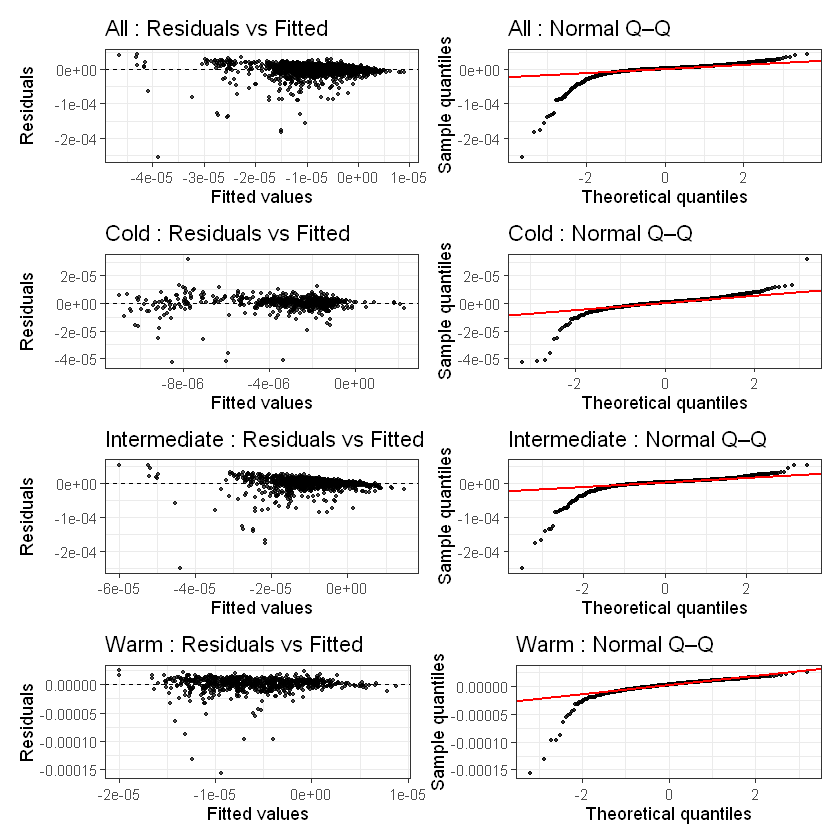

In [ ]:
library(lme4)
library(lmerTest)
library(dplyr)
library(readr)
library(ggplot2)
library(patchwork)

df <- read_csv("D:/NC/Data/rivernet/inputdata/Richness_slope.csv")

df <- df %>%
  mutate(
    SiteID   = as.character(SiteID),
    HYBAS_ID = as.character(HYBAS_ID),
    Protocol = as.character(Protocol),
    zone     = as.character(zone)
  )

num_cols <- c(
  "slope_LCBD",
  "mean_temp","slope_temp","mean_flow",
  "mean_organic","mean_salinity",
  "HFP_mean","elevation"
)

df[num_cols] <- lapply(df[num_cols], as.numeric)

df <- df %>%
  filter(
    complete.cases(
      slope_LCBD,
      mean_temp, slope_temp, mean_flow,
      mean_organic, mean_salinity,
      HFP_mean, elevation,
      Protocol, zone, HYBAS_ID
    )
  )

vars <- c(
  "mean_temp","slope_temp","mean_flow",
  "mean_organic","mean_salinity",
  "HFP_mean","elevation"
)

for (v in vars) {
  df[[paste0(v, "_z")]] <- scale(df[[v]])[, 1]
}

form <- slope_LCBD ~
  mean_temp_z + slope_temp_z + mean_flow_z +
  mean_organic_z + mean_salinity_z +
  HFP_mean_z + elevation_z +
  (1 | HYBAS_ID) + (1 | Protocol)

zones <- c("All", "Cold", "Intermediate", "Warm")

plot_list <- list()

for (z in zones) {

  dat <- if (z == "All") df else filter(df, zone == z)
  if (nrow(dat) < 50) next

  m <- lmer(
    form, data = dat, REML = TRUE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  diag_df <- data.frame(
    fitted = fitted(m),
    resid  = resid(m)
  )

  p1 <- ggplot(diag_df, aes(fitted, resid)) +
    geom_point(size = 0.8, alpha = 0.7) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(
      title = paste(z, ": Residuals vs Fitted"),
      x = "Fitted values",
      y = "Residuals"
    ) +
    theme_bw(base_size = 11)

  p2 <- ggplot(diag_df, aes(sample = resid)) +
    stat_qq(size = 0.8, alpha = 0.8) +
    stat_qq_line(color = "red", linewidth = 0.8) +
    labs(
      title = paste(z, ": Normal Q–Q"),
      x = "Theoretical quantiles",
      y = "Sample quantiles"
    ) +
    theme_bw(base_size = 11)

  plot_list[[z]] <- p1 + p2
}


final_plot <- wrap_plots(plot_list, ncol = 1)
final_plot
ggsave(
  filename = "C:/Users/Lenovo/Desktop/S3.png",
  plot = final_plot,
  width = 10,
  height = 12,
  dpi = 300
)



Rows: 3417 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): SiteID, Protocol, FlowClass, elev_class, HFP_class, geometry, zone
dbl (27): start_year, end_year, n_obs, slope_richness, p_richness, slope_tem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



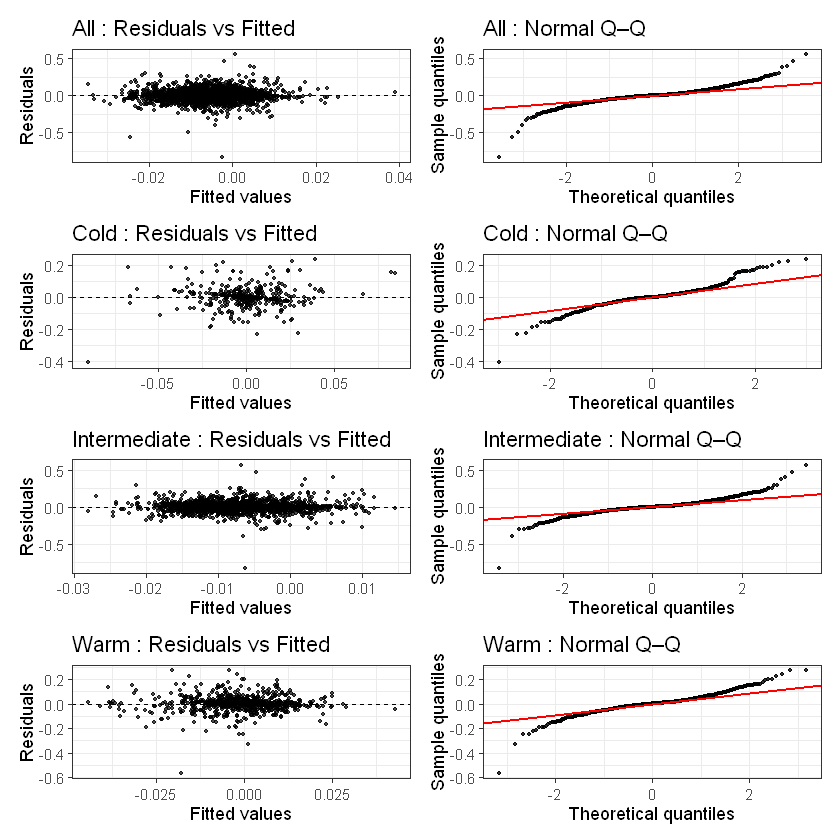

In [ ]:
library(lme4)
library(lmerTest)
library(dplyr)
library(readr)
library(ggplot2)
library(patchwork)

df <- read_csv("D:/NC/Data/rivernet/inputdata/Richness_slope.csv")

df <- df %>%
  mutate(
    SiteID   = as.character(SiteID),
    HYBAS_ID = as.character(HYBAS_ID),
    Protocol = as.character(Protocol),
    zone     = as.character(zone)
  )

num_cols <- c(
  "slope_Fdis",
  "mean_temp","slope_temp","mean_flow",
  "mean_organic","mean_salinity",
  "HFP_mean","elevation"
)
df[num_cols] <- lapply(df[num_cols], as.numeric)

df <- df %>%
  filter(
    complete.cases(
      slope_Fdis,
      mean_temp, slope_temp, mean_flow,
      mean_organic, mean_salinity,
      HFP_mean, elevation,
      Protocol, zone, HYBAS_ID
    )
  )

vars <- c(
  "mean_temp","slope_temp","mean_flow",
  "mean_organic","mean_salinity",
  "HFP_mean","elevation"
)

for (v in vars) {
  df[[paste0(v, "_z")]] <- scale(df[[v]])[, 1]
}

form <- slope_Fdis ~
  mean_temp_z + slope_temp_z + mean_flow_z +
  mean_organic_z + mean_salinity_z +
  HFP_mean_z + elevation_z +
  (1 | HYBAS_ID) + (1 | Protocol)

zones <- c("All", "Cold", "Intermediate", "Warm")
plots <- list()

for (z in zones) {

  dat <- if (z == "All") df else filter(df, zone == z)
  if (nrow(dat) < 50) next

  m <- lmer(
    form, data = dat, REML = TRUE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  diag_df <- data.frame(
    fitted = fitted(m),
    resid  = resid(m)
  )

  p1 <- ggplot(diag_df, aes(fitted, resid)) +
    geom_point(size = 0.8, alpha = 0.7) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(
      title = paste(z, ": Residuals vs Fitted"),
      x = "Fitted values",
      y = "Residuals"
    ) +
    theme_bw(base_size = 11)

  p2 <- ggplot(diag_df, aes(sample = resid)) +
    stat_qq(size = 0.8, alpha = 0.8) +
    stat_qq_line(color = "red", linewidth = 0.8) +
    labs(
      title = paste(z, ": Normal Q–Q"),
      x = "Theoretical quantiles",
      y = "Sample quantiles"
    ) +
    theme_bw(base_size = 11)

  plots[[z]] <- p1 + p2
}

final_plot <- wrap_plots(plots, ncol = 1)
final_plot
ggsave(
  "C:/Users/Lenovo/Desktop/S4.png",
  plot = final_plot,
  width = 10,
  height = 12,
  dpi = 300
)